## **GIAI ĐOẠN 2. EDA dữ liệu đã qua tiền xử lý**
---
## Mô tả pipeline EDA

Notebook này thực hiện phân tích khám phá dữ liệu trên tập **final unscaled data**, tức là tập dữ liệu cuối cùng sau các bước gom dữ liệu, tạo feature và mã hóa cơ bản, nhưng **chưa thực hiện scaling/standardization**. Việc EDA trên dữ liệu chưa scale giúp giữ nguyên ý nghĩa gốc của các biến định lượng như giá tiền, thời gian mở cửa, tọa độ địa lý và số lượng nhóm cuisine, từ đó hỗ trợ nhận xét phân phối dữ liệu một cách trực quan và dễ diễn giải hơn.

Pipeline EDA trong notebook được triển khai theo 14 bước chính:

1. **Import Libraries & Configuration**
   Import các thư viện cần thiết như `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy` và thiết lập cấu hình hiển thị, màu sắc, kích thước biểu đồ để đảm bảo notebook có định dạng thống nhất.

2. **Load Final Unscaled Data**
   Đọc tập dữ liệu final unscaled vào notebook, kiểm tra kích thước dữ liệu, danh sách cột và một số dòng mẫu để xác nhận dữ liệu được nạp đúng.

3. **Dataset Overview**
   Quan sát tổng quan dữ liệu thông qua shape, kiểu dữ liệu, thống kê mô tả và cấu trúc các cột. Bước này giúp nắm được dữ liệu gồm bao nhiêu dòng, bao nhiêu cột và các nhóm biến chính.

4. **Data Quality Check**
   Kiểm tra chất lượng dữ liệu, bao gồm missing values, infinite values, duplicate rows, feature hằng số/gần hằng số và các bất thường logic như `Price_range < 0`. Các dòng duplicate được loại bỏ trước khi thực hiện các phân tích chính thức để tránh làm sai lệch thống kê.

5. **Target Analysis**
   Phân tích phân bố của biến mục tiêu `preference_level` sau khi đã loại bỏ duplicate. Bước này giúp đánh giá mức độ mất cân bằng lớp và định hướng lựa chọn metric phù hợp ở giai đoạn mô hình hóa.

6. **Feature Type Analysis**
   Phân loại các feature thành nhóm biến nhị phân/one-hot và nhóm biến định lượng liên tục. Việc tách nhóm feature giúp lựa chọn cách phân tích, trực quan hóa và kiểm tra outlier phù hợp cho từng loại biến.

7. **Continuous Feature Analysis**
   Phân tích các biến định lượng liên tục thông qua thống kê mô tả, histogram và boxplot. Vì dữ liệu chưa scale nên các biến như giá tiền, số lượng đánh giá, thời gian và tọa độ vẫn giữ đơn vị gốc, giúp việc diễn giải có ý nghĩa hơn.

8. **Binary / One-hot Feature Analysis**
   Phân tích các biến nhị phân hoặc one-hot bằng cách kiểm tra tỷ lệ xuất hiện của giá trị 1. Bước này giúp nhận diện các feature thưa, ít phổ biến hoặc gần như không có thông tin phân biệt.

9. **Feature Analysis by Target**
   So sánh một số feature quan trọng theo từng nhóm `preference_level`. Mục tiêu của bước này là quan sát sự khác biệt về phân phối feature giữa các lớp target, từ đó hỗ trợ hiểu dữ liệu và định hướng mô hình hóa.

10. **Correlation Analysis**
    Phân tích tương quan giữa các biến numeric và giữa feature với target. Để không làm thay đổi dữ liệu gốc, biến `preference_level_numeric` chỉ được tạo trong dataframe phụ `corr_df`, trong đó target được mã hóa theo đúng thứ tự `low = 0`, `moderate = 1`, `high = 2`.

11. **Geographic Analysis**
    Phân tích phân bố địa lý dựa trên hai cột `Latitude` và `Longitude`. Bước này giúp quan sát sự tập trung của dữ liệu theo khu vực, đồng thời hỗ trợ phát hiện các điểm tọa độ bất thường nếu có.

12. **Outlier Analysis**
    Kiểm tra outlier cho các biến định lượng bằng phương pháp IQR. Với các feature có IQR bằng 0 hoặc phân phối tập trung mạnh tại một giá trị, kết quả outlier được diễn giải thận trọng vì đây có thể là đặc trưng của dữ liệu thưa hoặc zero-inflated, không nhất thiết là lỗi dữ liệu.

13. **Statistical Tests**
    Thực hiện một số kiểm định thống kê hỗ trợ EDA, bao gồm Chi-square test cho các biến nhị phân/one-hot và Kruskal-Wallis test cho các biến liên tục. Các kiểm định này chỉ dùng để khảo sát mối liên hệ thống kê với `preference_level`, không dùng để kết luận quan hệ nhân quả.

14. **Summary of Findings**
    Tổng hợp các phát hiện chính từ quá trình EDA, bao gồm kích thước dữ liệu sau khi loại duplicate, phân bố target, số lượng feature, tình trạng missing/duplicate, feature thưa, outlier, bất thường giá và các điểm cần lưu ý trước khi đưa dữ liệu vào pipeline mô hình hóa.
---

## 1. Import & Config

In [1]:
# Import các thư viện cần thiết

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from pathlib import Path
import math

# Cấu hình hiển thị dataframe
set_configs()

## 2. Load Final Unscaled Data

In [2]:
# Khai báo đường dẫn project
DATA_FOLDER = (Path.cwd().resolve().parent.parent / 'data')

# Đường dẫn file dữ liệu Train chưa scaled
DATA_PATH = DATA_FOLDER / "data_processed" / "train" / "train_unscaled.csv"

print("Data root:", DATA_FOLDER)
print("Đường dẫn dữ liệu:", DATA_PATH)
print("File tồn tại:", DATA_PATH.exists())

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Không tìm thấy file unscaled_data.csv. "
        "Hãy kiểm tra lại đường dẫn PROJECT_ROOT hoặc vị trí file dữ liệu."
    )

# Đọc dữ liệu
final_df = pd.read_csv(DATA_PATH)
final_df.head()

Data root: D:\HOC_TREN_TRUONG\TIEN_XU_LY&XD_DL\DO_AN\notebook\DS108.Q21\data
Đường dẫn dữ liệu: D:\HOC_TREN_TRUONG\TIEN_XU_LY&XD_DL\DO_AN\notebook\DS108.Q21\data\data_processed\train\train_unscaled.csv
File tồn tại: True


,Latitude,Longitude,Has_Online_delivery,Has_Table_booking,Has_Wifi,Min_Price,Max_Price,Avg_Price,Price_range,Style_American,Style_Asian,Style_Cambodian,Style_Chinese,Style_European,Style_Filipino,Style_French,Style_German,Style_International,Style_Italian,Style_Japanese,Style_Korean,Style_Malaysian,Style_Other,Style_Singaporean,Style_Spanish,Style_Taiwanese,Style_Thai,Style_Vietnamese,Cuisines_MainDish,Cuisines_Beverage,Cuisines_Dessert,Cuisines_Snack,Is_Vegetarian,Is_Healthy,Cuisines_VarietyScore,Type_Other,Type_buffet,Type_café/dessert,Type_khu ẩm thực,Type_nhà hàng,Type_nhà hàng sang trọng,Type_quán cơm văn phòng,Type_quán nhậu,Type_quán ăn,Type_shop online,Type_tiệm bánh,Type_ăn vặt/vỉa hè,Same_Min_Max,Avg_open_hour,Avg_close_hour,Is_open_after_22,Avg_open_duration,Is_open_weekend,preference_level
0,10.753505,106.643005,0,0,0,5000.0,170000.0,90000.0,167500.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,5,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,7.5,22.0,0,14.5,1,low
1,10.790203,106.657030,0,1,0,20000.0,55000.0,47500.0,45000.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,10,2,0,1,0,0,3,0,0,0,0,0,0,0,0,1,0,0,0,0,7.0,22.0,0,15.0,1,low
2,10.792780,106.709070,0,0,0,19000.0,100442.0,69221.0,90942.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,5,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,7.0,23.5,1,16.5,1,high
3,10.835960,106.766730,0,1,1,19125.0,87734.0,62992.0,78171.5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,10.0,20.0,0,10.0,1,high
4,10.858743,106.627250,0,0,0,15000.0,45000.0,37500.0,37500.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,3,0,0,3,0,0,2,0,0,0,0,0,0,0,0,1,0,0,0,0,7.0,23.0,1,16.0,1,high


## 3. Dataset Overview

In [3]:
# Kiểm tra kích thước dữ liệu
print("Kích thước dữ liệu")
print("Số dòng:", final_df.shape[0])
print("Số cột:", final_df.shape[1])

Kích thước dữ liệu
Số dòng: 9768
Số cột: 54


In [4]:
# Kiểm tra danh sách cột
print('Danh sách cột:', final_df.columns.tolist())

Danh sách cột: ['Latitude', 'Longitude', 'Has_Online_delivery', 'Has_Table_booking', 'Has_Wifi', 'Min_Price', 'Max_Price', 'Avg_Price', 'Price_range', 'Style_American', 'Style_Asian', 'Style_Cambodian', 'Style_Chinese', 'Style_European', 'Style_Filipino', 'Style_French', 'Style_German', 'Style_International', 'Style_Italian', 'Style_Japanese', 'Style_Korean', 'Style_Malaysian', 'Style_Other', 'Style_Singaporean', 'Style_Spanish', 'Style_Taiwanese', 'Style_Thai', 'Style_Vietnamese', 'Cuisines_MainDish', 'Cuisines_Beverage', 'Cuisines_Dessert', 'Cuisines_Snack', 'Is_Vegetarian', 'Is_Healthy', 'Cuisines_VarietyScore', 'Type_Other', 'Type_buffet', 'Type_café/dessert', 'Type_khu ẩm thực', 'Type_nhà hàng', 'Type_nhà hàng sang trọng', 'Type_quán cơm văn phòng', 'Type_quán nhậu', 'Type_quán ăn', 'Type_shop online', 'Type_tiệm bánh', 'Type_ăn vặt/vỉa hè', 'Same_Min_Max', 'Avg_open_hour', 'Avg_close_hour', 'Is_open_after_22', 'Avg_open_duration', 'Is_open_weekend', 'preference_level']


In [5]:
# Kiểm tra kiểu dữ liệu
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9768 entries, 0 to 9767
Data columns (total 54 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Latitude                  9768 non-null   float64
 1   Longitude                 9768 non-null   float64
 2   Has_Online_delivery       9768 non-null   int64  
 3   Has_Table_booking         9768 non-null   int64  
 4   Has_Wifi                  9768 non-null   int64  
 5   Min_Price                 9768 non-null   float64
 6   Max_Price                 9768 non-null   float64
 7   Avg_Price                 9768 non-null   float64
 8   Price_range               9768 non-null   float64
 9   Style_American            9768 non-null   int64  
 10  Style_Asian               9768 non-null   int64  
 11  Style_Cambodian           9768 non-null   int64  
 12  Style_Chinese             9768 non-null   int64  
 13  Style_European            9768 non-null   int64  
 14  Style_Filipino     

In [6]:
# Thống kê số lượng cột theo kiểu dữ liệu

dtype_summary = (
    final_df.dtypes
    .astype(str)
    .value_counts()
    .reset_index()
)

dtype_summary.columns = ["Kiểu dữ liệu", "Số lượng cột"]

dtype_summary

,Kiểu dữ liệu,Số lượng cột
0,int64,44
1,float64,9
2,str,1


### Nhận xét

_ Tập dữ liệu này là phiên bản final **chưa scale**, được dùng để EDA vì các feature liên tục vẫn giữ đơn vị gốc và dễ diễn giải hơn trong báo cáo.\
_ Sau EDA, nhóm có tạo thêm bản đã scale để phục vụ các mô hình nhạy cảm với thang đo dữ liệu.

## 4. Data Quality Check

### 4.1 Missing values

In [7]:
# Kiểm tra missing values trong dữ liệu final chưa scale

missing_final = (
    final_df
    .isna()
    .sum()
    .reset_index()
)

missing_final.columns = ["column", "missing_count"]

missing_final["missing_ratio"] = (
    missing_final["missing_count"] / len(final_df) * 100
).round(2)

missing_final = missing_final.sort_values("missing_count", ascending=False)

missing_final_display = missing_final[
    missing_final["missing_count"] > 0
]

missing_final_display

,column,missing_count,missing_ratio


In [8]:
# Tổng số giá trị thiếu trong toàn bộ dữ liệu

total_missing = int(final_df.isna().sum().sum())

print("Tổng số giá trị thiếu:", total_missing)

Tổng số giá trị thiếu: 0


### 4.2 Infinite values

In [9]:
# Kiểm tra giá trị vô hạn trong các cột numeric

numeric_all_cols = final_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

total_infinite = np.isinf(final_df[numeric_all_cols]).sum().sum()

print("Tổng số giá trị vô hạn:", int(total_infinite))

Tổng số giá trị vô hạn: 0


### 4.3 Duplicate rows

Dù đã lọc trùng trong quá trình tiền xử lý dựa vào các cột: Restaurant Name, Latitude, Longitude, nhưng sau khi bỏ cột Restaurant Name vẫn còn các dòng trùng do giá trị Latitude, Longitude của nó giống nhau (do cùng 1 cơ sở chung). Nên nhóm tiến hành lọc trùng thêm 1 lần nữa

In [10]:
# Kiểm tra dòng trùng hoàn toàn

duplicate_rows_all = final_df[final_df.duplicated(keep=False)]
duplicate_rows_to_drop = int(final_df.duplicated(keep="first").sum())

print("Số dòng nằm trong nhóm trùng:", duplicate_rows_all.shape[0])
print("Số dòng trùng sẽ loại bỏ nếu giữ dòng đầu tiên:", duplicate_rows_to_drop)

duplicate_rows_all.head()

Số dòng nằm trong nhóm trùng: 0
Số dòng trùng sẽ loại bỏ nếu giữ dòng đầu tiên: 0


,Latitude,Longitude,Has_Online_delivery,Has_Table_booking,Has_Wifi,Min_Price,Max_Price,Avg_Price,Price_range,Style_American,Style_Asian,Style_Cambodian,Style_Chinese,Style_European,Style_Filipino,Style_French,Style_German,Style_International,Style_Italian,Style_Japanese,Style_Korean,Style_Malaysian,Style_Other,Style_Singaporean,Style_Spanish,Style_Taiwanese,Style_Thai,Style_Vietnamese,Cuisines_MainDish,Cuisines_Beverage,Cuisines_Dessert,Cuisines_Snack,Is_Vegetarian,Is_Healthy,Cuisines_VarietyScore,Type_Other,Type_buffet,Type_café/dessert,Type_khu ẩm thực,Type_nhà hàng,Type_nhà hàng sang trọng,Type_quán cơm văn phòng,Type_quán nhậu,Type_quán ăn,Type_shop online,Type_tiệm bánh,Type_ăn vặt/vỉa hè,Same_Min_Max,Avg_open_hour,Avg_close_hour,Is_open_after_22,Avg_open_duration,Is_open_weekend,preference_level


### 4.4 Check Price_range < 0

In [11]:
TARGET_COL = 'preference_level'
# Kiểm tra tính hợp lệ của các feature giá
price_cols = ["Min_Price", "Max_Price", "Avg_Price", "Price_range"]
existing_price_cols = [col for col in price_cols if col in final_df.columns]

invalid_price_rows = pd.DataFrame()

if set(["Min_Price", "Max_Price"]).issubset(final_df.columns):
    invalid_price_rows = final_df[
        final_df["Max_Price"] < final_df["Min_Price"]
    ]

    print("Số dòng có Max_Price < Min_Price:", invalid_price_rows.shape[0])

if "Price_range" in final_df.columns:
    invalid_price_range = final_df[
        final_df["Price_range"] < 0
    ]

    print("Số dòng có Price_range âm:", invalid_price_range.shape[0])

    display_cols = [col for col in ["Min_Price", "Max_Price", "Avg_Price", "Price_range", TARGET_COL] if col in final_df.columns]
    display(invalid_price_range[display_cols].head())

Số dòng có Max_Price < Min_Price: 0
Số dòng có Price_range âm: 0


,Min_Price,Max_Price,Avg_Price,Price_range,preference_level


### 4.5 Constant / near-constant features

In [12]:
# Kiểm tra feature hằng số và gần hằng số
feature_cols_temp = [col for col in final_df.columns if col != TARGET_COL]

constant_features = []
near_constant_features = []

for col in feature_cols_temp:
    value_counts = final_df[col].value_counts(normalize=True, dropna=False)

    if final_df[col].nunique(dropna=False) <= 1:
        constant_features.append(col)
    elif value_counts.iloc[0] >= 0.99:
        near_constant_features.append(col)

print("Số feature hằng số:", len(constant_features))
print("Số feature gần hằng số:", len(near_constant_features))

constant_near_constant_summary = pd.DataFrame([
    {
        "feature_type": "constant_features",
        "feature_count": len(constant_features),
        "features": constant_features if len(constant_features) > 0 else "Không có"
    },
    {
        "feature_type": "near_constant_features",
        "feature_count": len(near_constant_features),
        "features": near_constant_features if len(near_constant_features) > 0 else "Không có"
    }
])

constant_near_constant_summary

Số feature hằng số: 0
Số feature gần hằng số: 12


,feature_type,feature_count,features
0,constant_features,0,Không có
1,near_constant_features,12,"[Style_Cambodian, Style_French, Style_German, Style_International, Style_Malaysian, Style_Other, Style_Spanish, Is_Vegetarian, Is_Healthy, Type_kh..."


## 5. Target Analysis

In [13]:
# Khai báo biến mục tiêu

if TARGET_COL not in final_df.columns:
    raise ValueError(f"Không tìm thấy cột target: {TARGET_COL}")

# Kiểm tra phân bố biến mục tiêu

target_distribution = (
    final_df[TARGET_COL]
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
)

target_distribution.columns = [TARGET_COL, "count"]

target_distribution["ratio (%)"] = (
    target_distribution["count"] / target_distribution["count"].sum() * 100
).round(2)

target_distribution

,preference_level,count,ratio (%)
0,high,3517,36.01
1,low,3056,31.29
2,moderate,3195,32.71


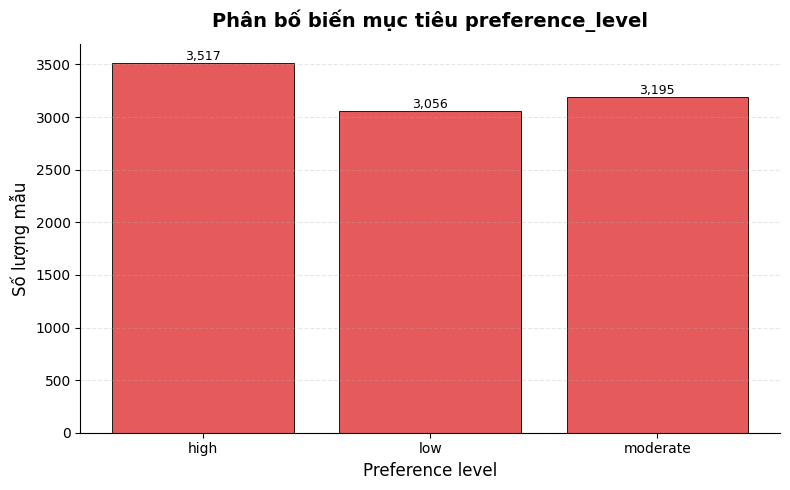

In [14]:
# Vẽ phân bố biến mục tiêu
plot_target(TARGET_COL, target_distribution)

### Nhận xét về mất cân bằng lớp
Ta thấy dữ liệu khi được gán nhãn bằng các ngưỡng xác định bằng quantile đã trở nên khá cân bằng

## 6. Feature Type Analysis

In [15]:
# Tách biến mục tiêu và feature

feature_cols = [
    col for col in final_df.columns
    if col != TARGET_COL
]

X = final_df[feature_cols]
y = final_df[TARGET_COL]

print("Số feature:", len(feature_cols))

Số feature: 53


In [16]:
# Nhóm các cột nhị phân/one-hot

binary_cols = []

for col in feature_cols:
    unique_values = set(final_df[col].dropna().unique())

    if unique_values.issubset({0, 1}):
        binary_cols.append(col)

print("Số biến nhị phân/one-hot:", len(binary_cols))
print(binary_cols)

Số biến nhị phân/one-hot: 39
['Has_Online_delivery', 'Has_Table_booking', 'Has_Wifi', 'Style_American', 'Style_Asian', 'Style_Cambodian', 'Style_Chinese', 'Style_European', 'Style_Filipino', 'Style_French', 'Style_German', 'Style_International', 'Style_Italian', 'Style_Japanese', 'Style_Korean', 'Style_Malaysian', 'Style_Other', 'Style_Singaporean', 'Style_Spanish', 'Style_Taiwanese', 'Style_Thai', 'Style_Vietnamese', 'Is_Vegetarian', 'Is_Healthy', 'Type_Other', 'Type_buffet', 'Type_café/dessert', 'Type_khu ẩm thực', 'Type_nhà hàng', 'Type_nhà hàng sang trọng', 'Type_quán cơm văn phòng', 'Type_quán nhậu', 'Type_quán ăn', 'Type_shop online', 'Type_tiệm bánh', 'Type_ăn vặt/vỉa hè', 'Same_Min_Max', 'Is_open_after_22', 'Is_open_weekend']


In [17]:
# Nhóm các cột định lượng không nhị phân

numeric_cols = final_df[feature_cols].select_dtypes(include=["int64", "float64"]).columns.tolist()

continuous_cols = [
    col for col in numeric_cols
    if col not in binary_cols
]

print("Số biến định lượng không nhị phân:", len(continuous_cols))
print(continuous_cols)

Số biến định lượng không nhị phân: 14
['Latitude', 'Longitude', 'Min_Price', 'Max_Price', 'Avg_Price', 'Price_range', 'Cuisines_MainDish', 'Cuisines_Beverage', 'Cuisines_Dessert', 'Cuisines_Snack', 'Cuisines_VarietyScore', 'Avg_open_hour', 'Avg_close_hour', 'Avg_open_duration']


In [18]:
# Tổng hợp số lượng feature theo nhóm
feature_type_summary = pd.DataFrame([
    {"Nhóm feature": "Biến nhị phân/one-hot", "Số lượng": len(binary_cols)},
    {"Nhóm feature": "Biến định lượng không nhị phân", "Số lượng": len(continuous_cols)}
])

display(feature_type_summary)

,Nhóm feature,Số lượng
0,Biến nhị phân/one-hot,39
1,Biến định lượng không nhị phân,14


## 7. Continuous Feature Analysis

In [19]:
# Thống kê mô tả các biến định lượng không nhị phân

continuous_summary = final_df[continuous_cols].describe().T

display(continuous_summary)

,count,mean,std,min,25%,50%,75%,max
Latitude,9768.0,10.748056,0.258732,8.678022,10.753150,10.791145,10.838695,2.131401e+01
Longitude,9768.0,106.633448,0.320721,104.908480,106.644109,106.681055,106.715985,1.075554e+02
Min_Price,9768.0,27601.191544,20379.057320,0.000000,15000.000000,20988.000000,32000.000000,2.000000e+05
Max_Price,9768.0,108174.948301,105957.815111,30.000000,40000.000000,65000.000000,150000.000000,1.182500e+06
Avg_Price,9768.0,81688.665694,67738.228460,30.000000,37500.000000,57500.000000,105000.000000,6.262500e+05
Price_range,9768.0,94374.352529,99822.282610,22.500000,30000.000000,52500.000000,130013.000000,1.175000e+06
Cuisines_MainDish,9768.0,1.697174,2.211372,0.000000,0.000000,1.000000,3.000000,1.900000e+01
Cuisines_Beverage,9768.0,1.106777,1.801835,0.000000,0.000000,0.000000,2.000000,9.000000e+00
Cuisines_Dessert,9768.0,0.165643,0.434037,0.000000,0.000000,0.000000,0.000000,5.000000e+00
Cuisines_Snack,9768.0,0.632371,1.058871,0.000000,0.000000,0.000000,1.000000,2.100000e+01


In [20]:
# Chọn các biến continuous quan trọng để vẽ

important_continuous_cols = [
    "Min_Price",
    "Max_Price",
    "Avg_Price",
    "Price_range",
    "Avg_open_duration",
    "Avg_open_hour"
]

important_continuous_cols = [
    col for col in important_continuous_cols
    if col in final_df.columns
]
print("Các biến continuous quan trọng để vẽ")
print(important_continuous_cols)

Các biến continuous quan trọng để vẽ
['Min_Price', 'Max_Price', 'Avg_Price', 'Price_range', 'Avg_open_duration', 'Avg_open_hour']


### Lưu ý về cách vẽ histogram cho feature liên tục

Một số feature liên tục có thể có khoảng giá trị rất rộng hoặc có ngoại lệ mạnh, làm histogram bị kéo dài và khó đọc.  
Vì vậy, các histogram dưới đây chỉ giới hạn vùng hiển thị trong khoảng **percentile 1%–99%**. Việc này chỉ phục vụ trực quan hóa, không làm thay đổi dữ liệu gốc.

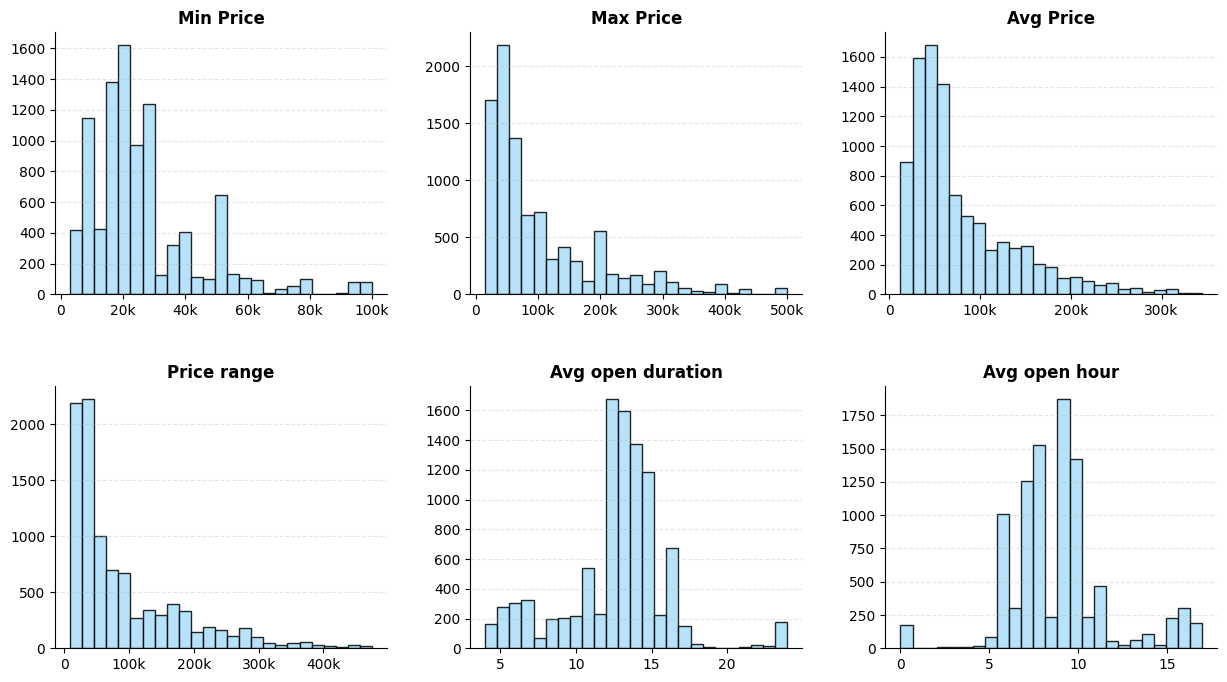

In [21]:
# Vẽ histogram các biến continuous quan trọng
cols = important_continuous_cols

n_features = len(cols)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(15, 4*n_rows)
)

axes = axes.flatten()

for i, col in enumerate(cols):

    plot_hist_percentile(
        ax=axes[i],
        data=final_df,
        col=col,
        title=col.replace("_", " "),
        bins=25,
        lower_q=0.01,
        upper_q=0.99,
        color="#A9DEF9"
    )

# Ẩn các ô thừa
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.subplots_adjust(
    hspace=0.35,
    wspace=0.25
)

plt.show()

## 8. Binary / One-hot Feature Analysis

In [22]:
# Tính tỷ lệ giá trị 1 của các biến nhị phân/one-hot

binary_ratio = []

for col in binary_cols:
    binary_ratio.append({
        "feature": col,
        "positive_count": int(final_df[col].sum()),
        "positive_ratio": round(final_df[col].mean() * 100, 2)
    })

binary_ratio_df = pd.DataFrame(binary_ratio).sort_values(
    "positive_ratio",
    ascending=False
)

display(binary_ratio_df)

,feature,positive_count,positive_ratio
38,Is_open_weekend,9139,93.56
21,Style_Vietnamese,6869,70.32
2,Has_Wifi,4985,51.03
32,Type_quán ăn,4268,43.69
26,Type_café/dessert,2531,25.91
37,Is_open_after_22,2211,22.64
1,Has_Table_booking,2104,21.54
0,Has_Online_delivery,2025,20.73
4,Style_Asian,1491,15.26
28,Type_nhà hàng,1270,13.00


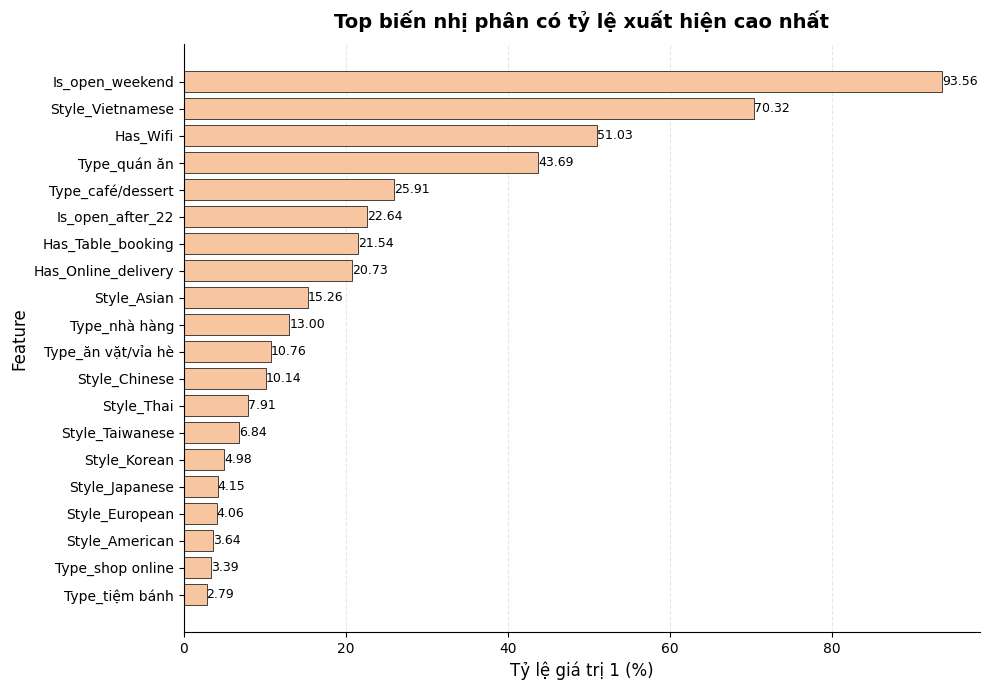

In [23]:
# Vẽ top 20 biến nhị phân có tỷ lệ xuất hiện cao nhất

plot_barh_beautiful(
    data=binary_ratio_df,
    category_col="feature",
    value_col="positive_ratio",
    title="Top biến nhị phân có tỷ lệ xuất hiện cao nhất",
    xlabel="Tỷ lệ giá trị 1 (%)",
    ylabel="Feature",
    color=PASTEL_COLORS["secondary"],
    top_n=20,
    value_format="{:.2f}"
)

### Nhận xét:
* Đa số các quán đều mở cửa vào cuối tuần, vì đây là khoảng thời gian thu hút nhiều lượt khách nhất
* Các quán thuộc phong cách Việt Nam chiếm thị phần lớn, trong khi các quán nước ngoài có tỉ lệ nhỏ, thể hiện đặc trưng của khu vực
* Loại hình quán ăn và quán cà phê có độ phổ biến cao nhất trong các loại hình

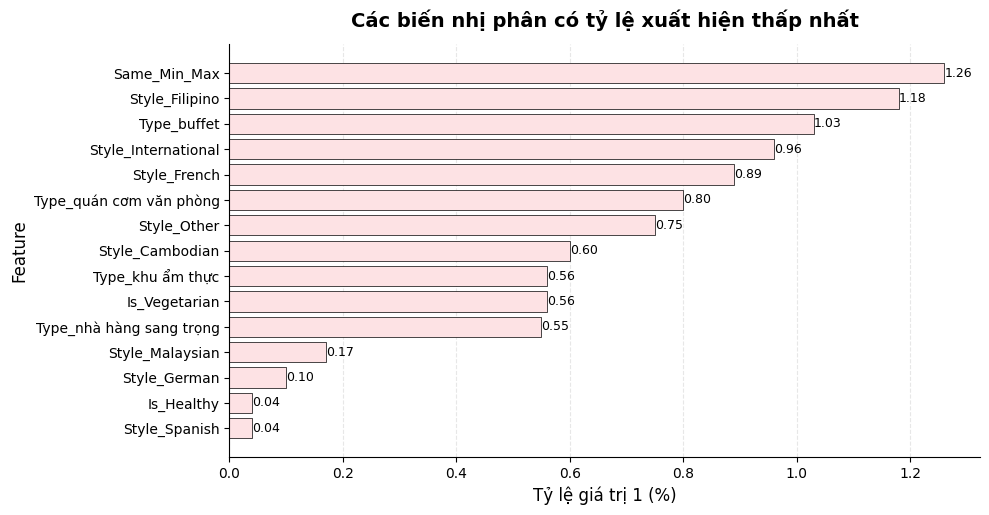

In [24]:
# Vẽ top 15 biến nhị phân hiếm nhất

rare_binary_features = binary_ratio_df.sort_values(
    "positive_ratio",
    ascending=True
).head(15)

plot_barh_beautiful(
    data=rare_binary_features,
    category_col="feature",
    value_col="positive_ratio",
    title="Các biến nhị phân có tỷ lệ xuất hiện thấp nhất",
    xlabel="Tỷ lệ giá trị 1 (%)",
    ylabel="Feature",
    color=PASTEL_COLORS["pink"],
    top_n=None,
    value_format="{:.2f}"
)

### Nhận xét

Các biến nhị phân/one-hot có mức độ xuất hiện không đồng đều. Một số biến xuất hiện rất phổ biến, trong khi một số biến rất hiếm.  
Các feature quá hiếm có thể ít đóng góp cho mô hình và làm tăng độ thưa của dữ liệu

## 9. Feature Analysis by Target

### 9.1 Continuous features by target

In [25]:
# So sánh trung bình các biến continuous theo từng lớp preference_level

continuous_by_target = (
    final_df
    .groupby(TARGET_COL)[important_continuous_cols]
    .mean()
    .T
)

continuous_by_target

preference_level,high,low,moderate
Min_Price,24348.206426,28755.889071,30077.558685
Max_Price,100924.212397,103886.542539,120258.267919
Avg_Price,74810.312624,80699.160340,90206.692645
Price_range,88750.109184,89508.598004,105219.488576
Avg_open_duration,12.459233,12.755801,12.415487
Avg_open_hour,8.683960,8.920935,9.069291


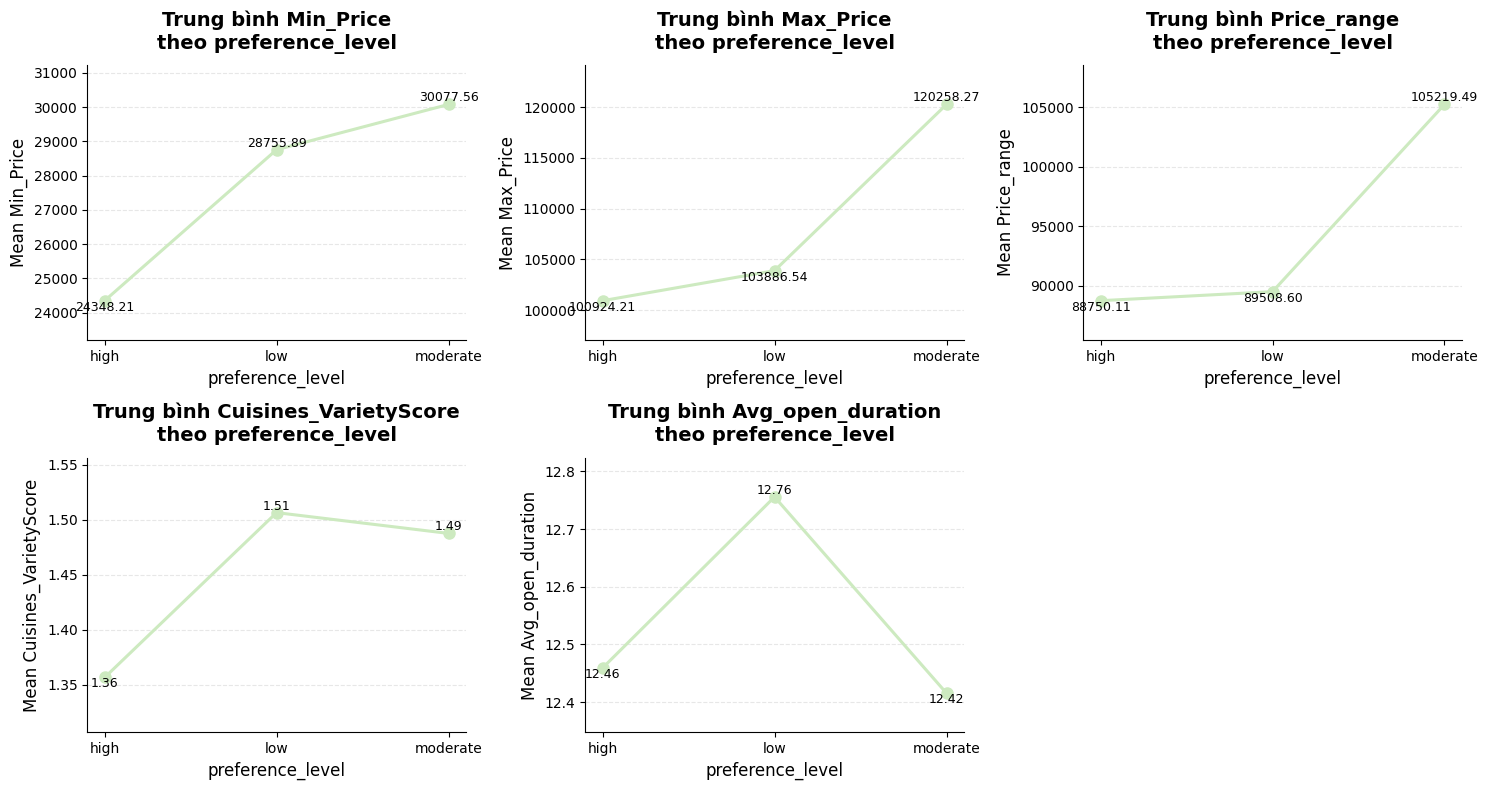

In [26]:
# Vẽ trung bình một số biến continuous theo preference_level

features_to_compare = [
    "Min_Price",
    "Max_Price",
    "Price_range",
    "Cuisines_VarietyScore",
    "Avg_open_duration"
]

features_to_compare = [
    col for col in features_to_compare
    if col in final_df.columns
]

n_features = len(features_to_compare)
n_cols = 3 
n_rows = math.ceil(n_features / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()
for i, col in enumerate(features_to_compare):
    plot_line_by_target(
        data=final_df,
        feature_col=col,
        target_col=TARGET_COL,
        title=f"Trung bình {col}\ntheo {TARGET_COL}",
        ylabel=f"Mean {col}",
        color=PASTEL_COLORS["green"],
        value_fmt="{:.2f}",
        ax=axes[i]  # TRUYỀN AXIS VÀO HÀM VẼ CỦA BẠN
    )
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### 9.2 Binary features by target

In [27]:
# So sánh tỷ lệ xuất hiện của các biến nhị phân theo từng lớp target

binary_by_target = (
    final_df
    .groupby(TARGET_COL)[binary_cols]
    .mean()
    .T
)

binary_by_target.head()

preference_level,high,low,moderate
Has_Online_delivery,0.172306,0.239529,0.215023
Has_Table_booking,0.178846,0.201898,0.268545
Has_Wifi,0.404322,0.536976,0.601565
Style_American,0.041228,0.035995,0.031612
Style_Asian,0.117998,0.171466,0.172770


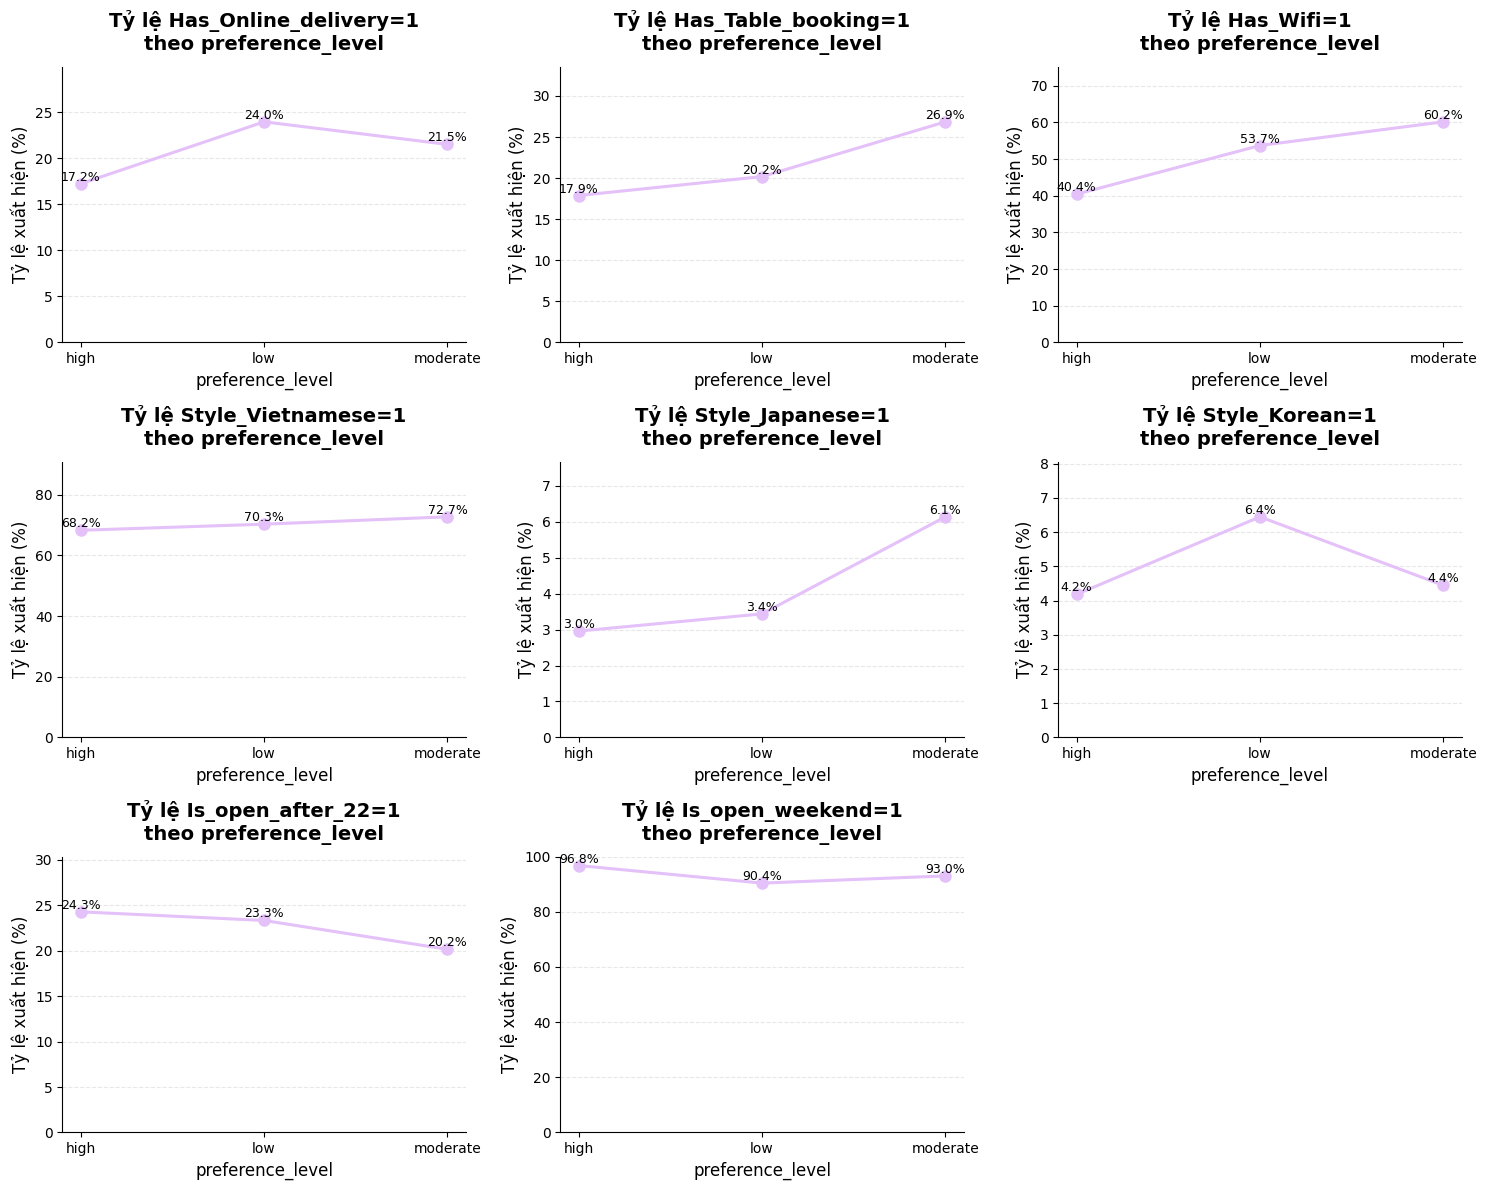

In [28]:
# Vẽ tỷ lệ xuất hiện của một số biến nhị phân theo target

binary_features_to_compare = [
    "Has_Online_delivery",
    "Has_Table_booking",
    "Has_Wifi",
    "Style_Vietnamese",
    "Style_Japanese",
    "Style_Korean",
    "Is_open_after_22",
    "Is_open_weekend"
]

binary_features_to_compare = [
    col for col in binary_features_to_compare
    if col in final_df.columns
]

n_binfeatures = len(binary_features_to_compare)
n_bincols = 3 
n_binrows = math.ceil(n_binfeatures / n_bincols)
fig, axes = plt.subplots(n_binrows, n_bincols, figsize=(n_bincols * 5, n_binrows * 4))
axes = axes.flatten()
for i, col in enumerate(binary_features_to_compare):
    plot_binary_ratio_by_target(
        data=final_df,
        feature_col=col,
        target_col=TARGET_COL,
        color=PASTEL_COLORS["accent"],
        ax=axes[i]
    )
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Nhận xét:
* Đa số các quán ở các mức độ đều hỗ trợ các tiện ích: giao tận nơi, đặt bàn trước, wifi, mở cửa sau 22h và vào cuối tuần

## 10. Correlation Analysis

In [29]:
# Kiểm tra kiểu dữ liệu của biến mục tiêu

print(final_df[TARGET_COL].dtype)

final_df[TARGET_COL].value_counts(dropna=False)

str


preference_level
high        3517
moderate    3195
low         3056
Name: count, dtype: int64

In [30]:
# Tạo bản copy riêng để phục vụ correlation
# Không thêm target numeric trực tiếp vào final_df để tránh làm lệch số cột dữ liệu gốc

TARGET_NUMERIC_COL = TARGET_COL + "_numeric"

target_order = {
    "low": 0,
    "moderate": 1,
    "high": 2
}

corr_df = final_df.copy()

if pd.api.types.is_numeric_dtype(corr_df[TARGET_COL]):
    corr_df[TARGET_NUMERIC_COL] = corr_df[TARGET_COL]
else:
    unknown_targets = set(corr_df[TARGET_COL].dropna().unique()) - set(target_order.keys())
    
    if len(unknown_targets) > 0:
        raise ValueError(f"Target có giá trị chưa được mapping: {unknown_targets}")
    
    corr_df[TARGET_NUMERIC_COL] = corr_df[TARGET_COL].map(target_order)

print("Target gốc:", TARGET_COL)
print("Target numeric:", TARGET_NUMERIC_COL)

corr_df[[TARGET_COL, TARGET_NUMERIC_COL]].drop_duplicates().sort_values(TARGET_NUMERIC_COL)

Target gốc: preference_level
Target numeric: preference_level_numeric


,preference_level,preference_level_numeric
0,low,0
7,moderate,1
2,high,2


In [31]:
# Tính tương quan giữa các feature numeric và biến mục tiêu numeric

numeric_corr_df = corr_df.corr(numeric_only=True)

correlation_with_target = (
    numeric_corr_df[TARGET_NUMERIC_COL]
    .drop(TARGET_NUMERIC_COL)
    .sort_values(key=abs, ascending=False)
    .reset_index()
)

correlation_with_target.columns = ["feature", "correlation_with_target"]

# Bỏ cột target gốc nếu vô tình có trong bảng
correlation_with_target = correlation_with_target[
    correlation_with_target["feature"] != TARGET_COL
]

correlation_with_target.head(20)

,feature,correlation_with_target
0,Has_Wifi,-0.113598
1,Is_open_weekend,0.106791
2,Style_Taiwanese,0.106220
3,Style_Chinese,0.100355
4,Cuisines_MainDish,-0.095505
5,Min_Price,-0.091829
6,Style_Thai,0.087761
7,Longitude,-0.081285
8,Cuisines_VarietyScore,-0.080979
9,Type_Other,-0.077800


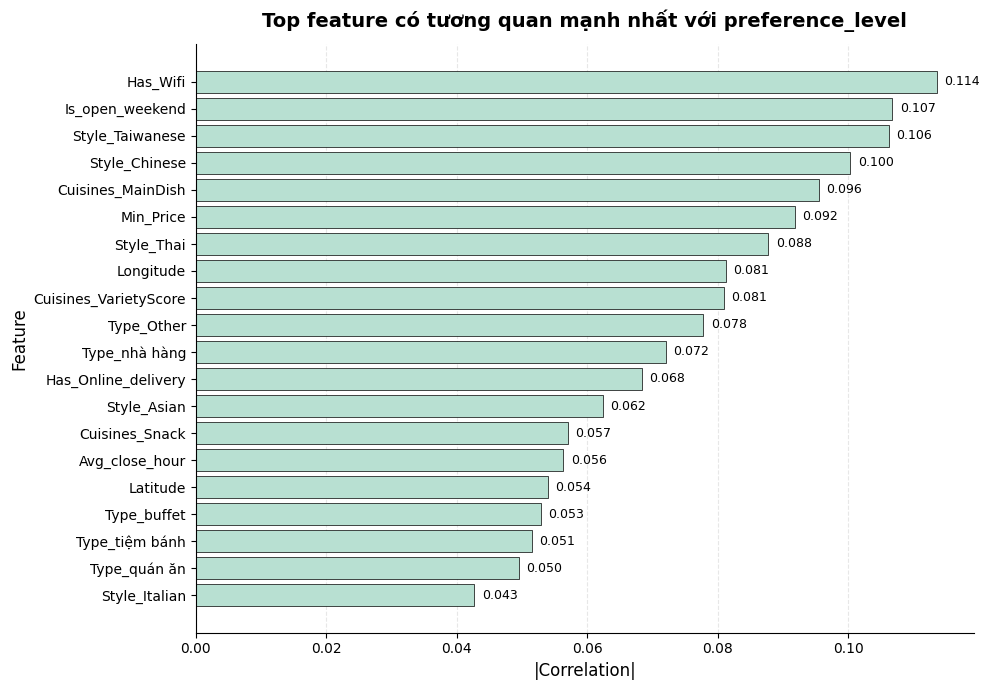

In [32]:
# Vẽ top 20 feature có tương quan mạnh nhất với target

top_corr_target = correlation_with_target.head(20).copy()
top_corr_target["abs_corr"] = top_corr_target["correlation_with_target"].abs()
top_corr_target = top_corr_target.sort_values("abs_corr", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    top_corr_target["feature"],
    top_corr_target["abs_corr"],
    color=PASTEL_COLORS["primary"],
    edgecolor="black",
    linewidth=0.5
)

ax.set_title("Top feature có tương quan mạnh nhất với preference_level", fontweight="bold", pad=12)
ax.set_xlabel("|Correlation|")
ax.set_ylabel("Feature")

ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

max_value = top_corr_target["abs_corr"].max()
offset = max_value * 0.01

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + offset,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        ha="left",
        fontsize=9
    )

plt.tight_layout()
plt.show()

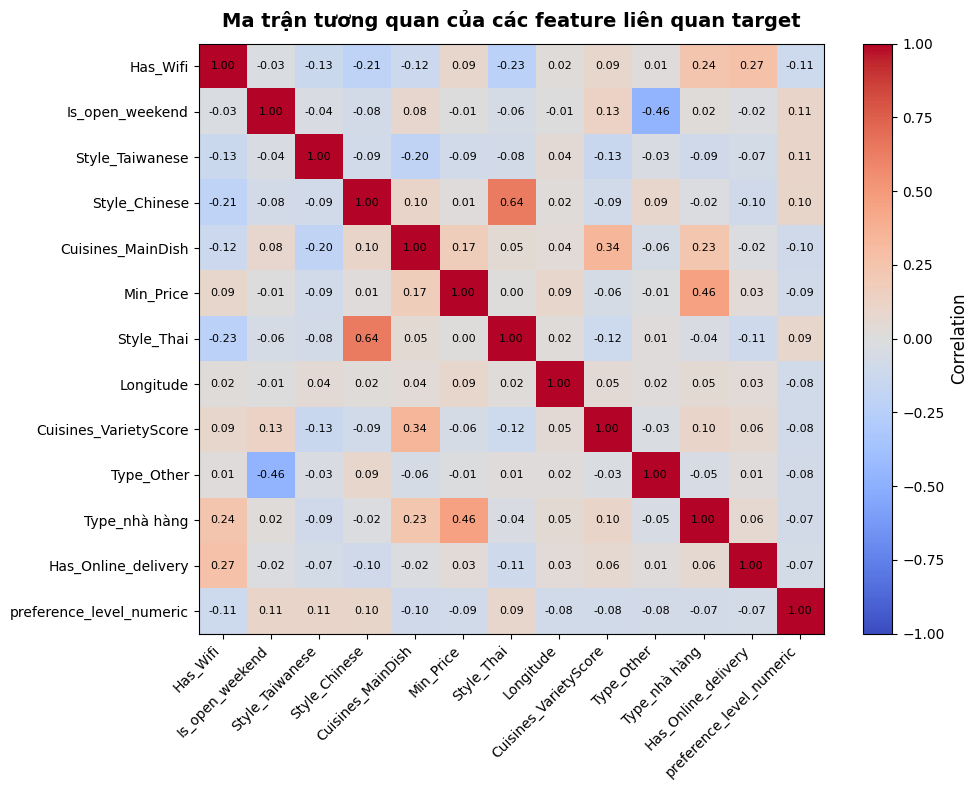

In [33]:
# Vẽ heatmap tương quan giữa target numeric và các feature liên quan nhất

top_corr_features = correlation_with_target.head(12)["feature"].tolist()
corr_cols = top_corr_features + [TARGET_NUMERIC_COL]
corr_matrix_small = corr_df[corr_cols].corr()
plt.figure(figsize=(10, 8))
plt.imshow(
    corr_matrix_small,
    cmap="coolwarm",
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    ticks=np.arange(len(corr_matrix_small.columns)),
    labels=corr_matrix_small.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(corr_matrix_small.index)),
    labels=corr_matrix_small.index
)

plt.title("Ma trận tương quan của các feature liên quan target", fontweight="bold", pad=12)

for i in range(len(corr_matrix_small.index)):
    for j in range(len(corr_matrix_small.columns)):
        plt.text(
            j,
            i,
            f"{corr_matrix_small.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

In [34]:
# Tính ma trận tương quan giữa toàn bộ các feature numeric
# Không đưa target vào ma trận này vì mục tiêu là xem tương quan giữa các feature với nhau

exclude_cols = [TARGET_COL]

# Nếu có cột target numeric thì cũng loại ra
if "TARGET_NUMERIC_COL" in globals():
    exclude_cols.append(TARGET_NUMERIC_COL)

feature_corr_cols = [
    col for col in corr_df.select_dtypes(include=["int64", "float64"]).columns
    if col not in exclude_cols
]

full_feature_corr = corr_df[feature_corr_cols].corr()

print("Số feature numeric dùng để tính tương quan:", len(feature_corr_cols))

full_feature_corr.head()

Số feature numeric dùng để tính tương quan: 53


,Latitude,Longitude,Has_Online_delivery,Has_Table_booking,Has_Wifi,Min_Price,Max_Price,Avg_Price,Price_range,Style_American,Style_Asian,Style_Cambodian,Style_Chinese,Style_European,Style_Filipino,Style_French,Style_German,Style_International,Style_Italian,Style_Japanese,Style_Korean,Style_Malaysian,Style_Other,Style_Singaporean,Style_Spanish,Style_Taiwanese,Style_Thai,Style_Vietnamese,Cuisines_MainDish,Cuisines_Beverage,Cuisines_Dessert,Cuisines_Snack,Is_Vegetarian,Is_Healthy,Cuisines_VarietyScore,Type_Other,Type_buffet,Type_café/dessert,Type_khu ẩm thực,Type_nhà hàng,Type_nhà hàng sang trọng,Type_quán cơm văn phòng,Type_quán nhậu,Type_quán ăn,Type_shop online,Type_tiệm bánh,Type_ăn vặt/vỉa hè,Same_Min_Max,Avg_open_hour,Avg_close_hour,Is_open_after_22,Avg_open_duration,Is_open_weekend
Latitude,1.000000,0.482549,0.045785,-0.016394,0.017141,0.028134,0.012299,0.018084,0.010183,0.014344,0.022996,0.015369,0.031394,0.000991,0.004274,0.008705,-0.007197,-0.006395,-0.001308,-0.002438,0.004846,0.007472,0.013203,0.026562,-0.019796,0.056960,0.032280,-0.062607,-0.014884,0.028935,0.007256,-0.002466,-0.006775,-0.006765,0.002034,0.037239,0.013300,0.026816,0.062422,0.010164,-0.009627,0.012839,-0.009642,-0.032352,0.023527,0.003244,-0.028569,-0.027102,-0.012013,0.041498,0.013555,0.036087,-0.044552
Longitude,0.482549,1.000000,0.034144,-0.021628,0.020152,0.091744,0.110382,0.113932,0.107802,0.012578,0.022998,0.005123,0.023301,0.020793,-0.009146,0.011380,-0.004541,0.000098,0.014397,0.009530,-0.006059,0.007689,0.011116,0.021560,-0.005132,0.039982,0.019095,-0.062167,0.035795,0.036110,0.024005,0.033631,0.003597,0.009942,0.045544,0.015210,-0.001748,0.004920,-0.010109,0.052034,0.013986,0.013074,-0.014894,-0.011043,0.013330,0.004328,-0.040651,-0.014128,-0.001411,0.030760,0.052893,0.035728,-0.007419
Has_Online_delivery,0.045785,0.034144,1.000000,0.157768,0.268035,0.034257,0.042462,0.043516,0.041575,0.066301,0.040659,-0.030088,-0.101451,0.050771,-0.023040,-0.005472,-0.000577,0.019435,0.028806,0.031720,0.023516,-0.015294,-0.035579,-0.011601,0.002131,-0.065517,-0.105947,-0.006086,-0.019276,0.003333,0.077141,0.094081,0.008768,-0.010351,0.060601,0.009157,0.102511,-0.031529,0.049269,0.055353,0.012961,0.050591,0.140908,-0.168425,0.228038,0.104808,-0.010499,-0.023779,0.021880,0.023749,-0.033410,-0.005641,-0.019139
Has_Table_booking,-0.016394,-0.021628,0.157768,1.000000,0.387694,0.152669,0.172875,0.181138,0.167916,-0.042101,0.064980,-0.027989,-0.092619,0.030882,-0.050263,0.000690,0.029949,0.042734,-0.004439,0.115878,-0.001928,0.002021,-0.013659,-0.037392,0.014012,-0.115320,-0.101938,0.014411,-0.001222,-0.148120,0.078314,0.138175,0.003838,0.014012,0.074844,0.004558,0.121230,-0.258704,0.047103,0.178778,0.095279,-0.030221,0.136466,-0.322987,0.160623,-0.029920,0.522069,0.054730,0.195964,0.008611,0.014138,-0.150076,-0.016756
Has_Wifi,0.017141,0.020152,0.268035,0.387694,1.000000,0.089147,0.060240,0.073934,0.054843,0.034227,0.134435,-0.066368,-0.210523,0.028412,-0.063963,-0.007410,0.012146,0.050405,-0.000459,0.128731,0.062139,-0.022974,-0.050541,-0.022718,0.019826,-0.129742,-0.227964,-0.010546,-0.120344,0.222409,0.014283,0.103214,-0.019347,-0.000419,0.087047,0.011972,0.063682,0.193194,0.029918,0.235573,0.050936,-0.015662,0.072434,-0.550430,0.125724,-0.069981,0.268084,0.000419,0.077879,0.089367,-0.003113,0.004475,-0.026696


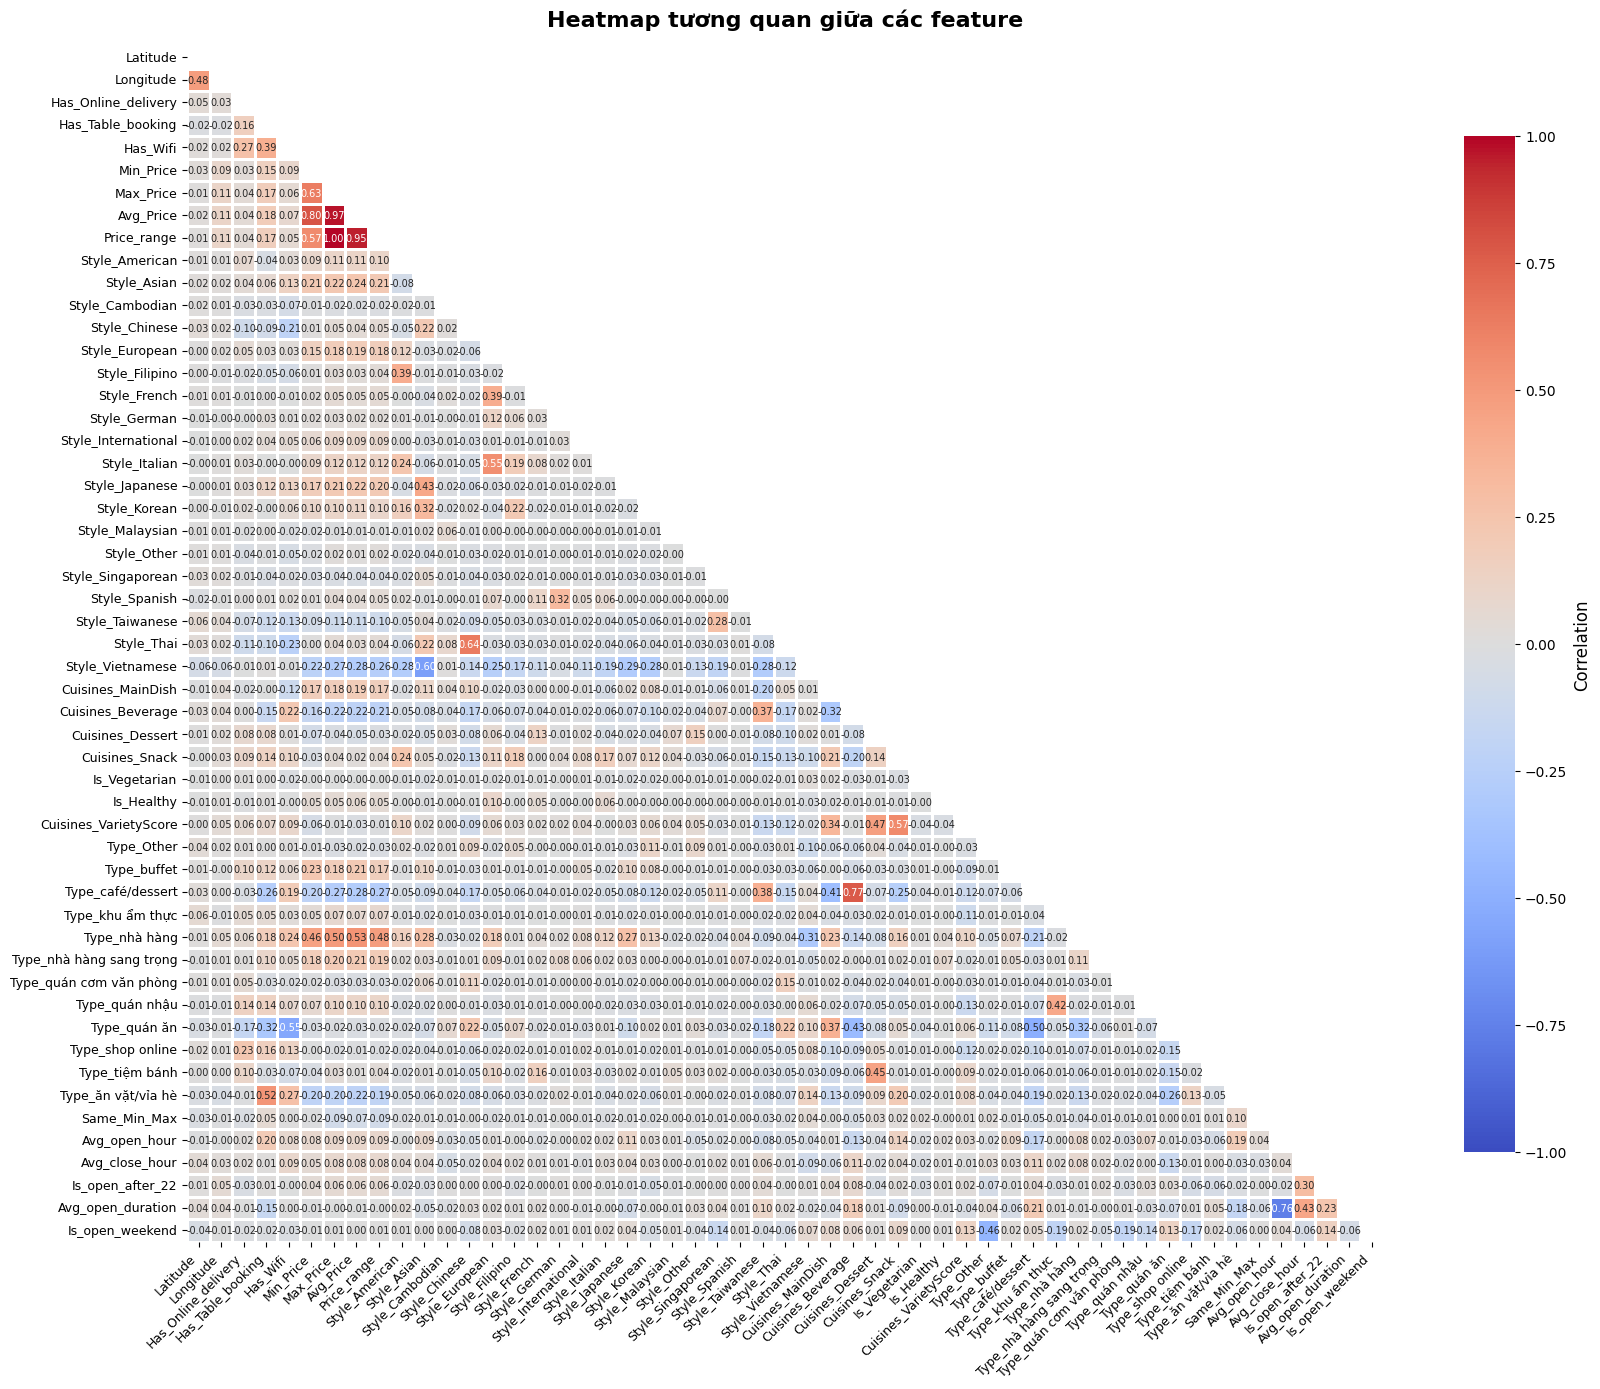

In [35]:
# Vẽ lại heatmap tương quan giữa tất cả các feature
import seaborn as sns

# Tính ma trận tương quan giữa toàn bộ feature numeric
exclude_cols = [TARGET_COL]

if "TARGET_NUMERIC_COL" in globals():
    exclude_cols.append(TARGET_NUMERIC_COL)

feature_corr_cols = [
    col for col in corr_df.select_dtypes(include=["int64", "float64"]).columns
    if col not in exclude_cols
]

full_feature_corr = corr_df[feature_corr_cols].corr()

# Chỉ hiển thị tam giác dưới để tránh lặp thông tin
mask = np.triu(np.ones_like(full_feature_corr, dtype=bool))

plt.figure(figsize=(18, 14))

sns.heatmap(
    full_feature_corr,
    mask=mask,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    linewidths=0.8,
    linecolor="white",
    square=True,
    cbar_kws={"label": "Correlation", "shrink": 0.85}
)

plt.title("Heatmap tương quan giữa các feature", fontsize=16, fontweight="bold", pad=14)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

In [36]:
# Tạo bảng top 20 cặp feature có tương quan mạnh nhất
# Chỉ lấy tương quan giữa các feature, không lấy target

exclude_cols = [TARGET_COL]

if "TARGET_NUMERIC_COL" in globals():
    exclude_cols.append(TARGET_NUMERIC_COL)

feature_corr_cols = [
    col for col in corr_df.select_dtypes(include=["int64", "float64"]).columns
    if col not in exclude_cols
]

full_feature_corr = corr_df[feature_corr_cols].corr()

# Chỉ lấy nửa trên của ma trận để tránh lặp cặp A-B và B-A
corr_pairs_abs = full_feature_corr.abs().where(
    np.triu(np.ones(full_feature_corr.shape), k=1).astype(bool)
)

top_corr_pairs = corr_pairs_abs.stack().reset_index()
top_corr_pairs.columns = ["feature_1", "feature_2", "abs_correlation"]

# Lấy thêm correlation gốc có dấu âm/dương
top_corr_pairs["correlation"] = top_corr_pairs.apply(
    lambda row: full_feature_corr.loc[row["feature_1"], row["feature_2"]],
    axis=1
)

top_corr_pairs = top_corr_pairs.sort_values(
    "abs_correlation",
    ascending=False
).head(20)

top_corr_pairs

,feature_1,feature_2,abs_correlation,correlation
326,Max_Price,Price_range,0.996871,0.996871
325,Max_Price,Avg_Price,0.972487,0.972487
379,Avg_Price,Price_range,0.951032,0.951032
272,Min_Price,Avg_Price,0.795763,0.795763
1574,Cuisines_Beverage,Type_café/dessert,0.772098,0.772098
2595,Avg_open_hour,Avg_open_duration,0.758759,-0.758759
662,Style_Chinese,Style_Thai,0.640437,0.640437
271,Min_Price,Max_Price,0.632790,0.632790
557,Style_Asian,Style_Vietnamese,0.600978,-0.600978
1677,Cuisines_Snack,Cuisines_VarietyScore,0.573727,0.573727


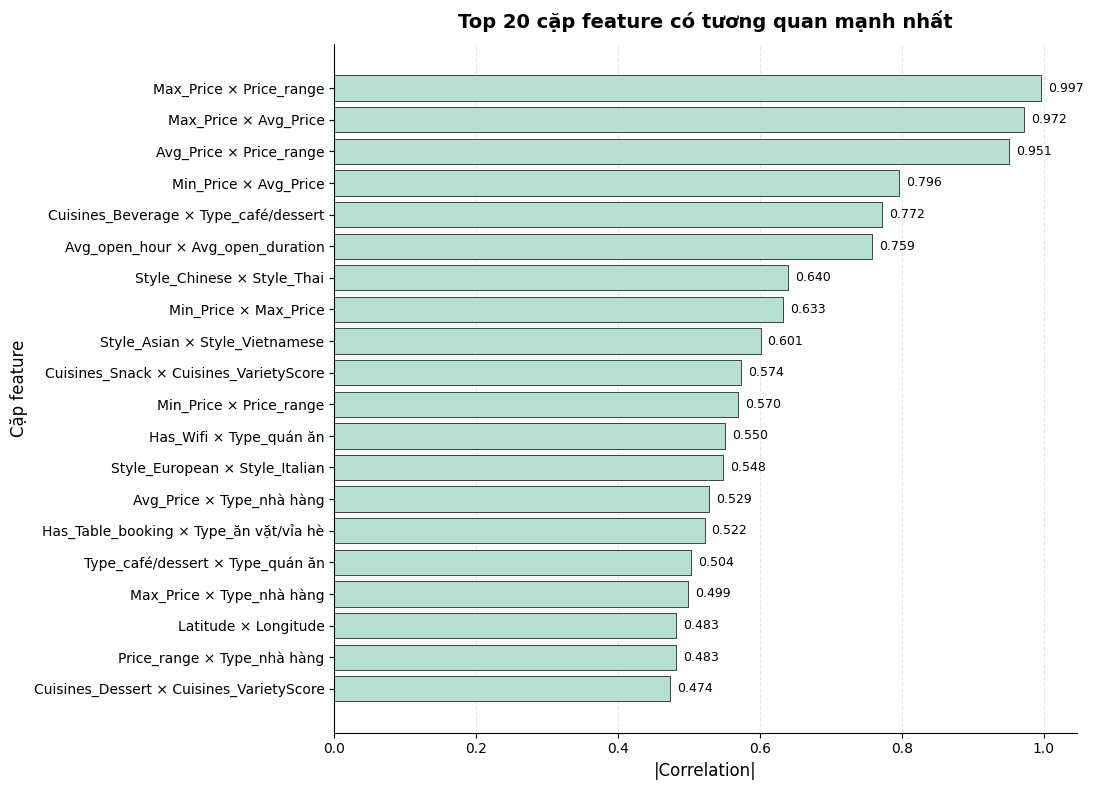

In [37]:
# Vẽ biểu đồ top 20 cặp feature có tương quan mạnh nhất

top_corr_pairs_plot = top_corr_pairs.copy()

top_corr_pairs_plot["feature_pair"] = (
    top_corr_pairs_plot["feature_1"] + " × " + top_corr_pairs_plot["feature_2"]
)

top_corr_pairs_plot = top_corr_pairs_plot.sort_values(
    "abs_correlation",
    ascending=True
)

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(
    top_corr_pairs_plot["feature_pair"],
    top_corr_pairs_plot["abs_correlation"],
    color=PASTEL_COLORS["primary"],
    edgecolor="black",
    linewidth=0.5
)

ax.set_title(
    "Top 20 cặp feature có tương quan mạnh nhất",
    fontweight="bold",
    pad=12
)

ax.set_xlabel("|Correlation|")
ax.set_ylabel("Cặp feature")

ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

max_value = top_corr_pairs_plot["abs_correlation"].max()
offset = max_value * 0.01

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + offset,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        ha="left",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Nhận xét
* Có thể thấy các cặp tương quan cao chủ yếu thuộc nhóm biến giá, như Max_Price, Avg_Price và Price_range. Điều này khá hợp lý vì các biến này đều được tạo ra từ cùng thông tin giá ban đầu nên có xu hướng mang thông tin gần nhau.
* Bên cạnh đó, Avg_open_hour và Avg_open_duration cũng có tương quan tương đối cao, phản ánh rằng thời điểm mở cửa có liên quan đến thời lượng hoạt động của cửa hàng.

Từ kết quả này, nhóm có thể nhận diện những nhóm đặc trưng gần nghĩa hoặc có khả năng chứa thông tin trùng lặp. Đây là cơ sở hữu ích nếu sau này tiếp tục thực hiện feature selection hoặc xây dựng mô hình phân loại.

## 11. Geography Analysis 

In [38]:
# Phân tích phân bố địa lý dựa trên Latitude và Longitude

geo_cols = ["Latitude", "Longitude"]

# Gom Latitude/Longitude thành các vùng nhỏ để kiểm tra mật độ dữ liệu

if all(col in final_df.columns for col in geo_cols):
    geo_df = final_df.dropna(subset=geo_cols).copy()

    geo_df["lat_bin"] = pd.cut(geo_df["Latitude"], bins=10)
    geo_df["lon_bin"] = pd.cut(geo_df["Longitude"], bins=10)

    geo_bin_count = (
        geo_df
        .groupby(["lat_bin", "lon_bin"], observed=True)
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    display(geo_bin_count.head(10))
else:
    print("Không tìm thấy đủ Latitude và Longitude trong dữ liệu.")

,lat_bin,lon_bin,count
6,"(9.942, 11.205]","(106.497, 106.761]",7305
7,"(9.942, 11.205]","(106.761, 107.026]",1116
8,"(9.942, 11.205]","(107.026, 107.291]",472
4,"(9.942, 11.205]","(105.703, 105.967]",464
3,"(9.942, 11.205]","(105.438, 105.703]",131
2,"(9.942, 11.205]","(105.173, 105.438]",109
1,"(9.942, 11.205]","(104.906, 105.173]",47
9,"(9.942, 11.205]","(107.291, 107.555]",42
0,"(8.665, 9.942]","(106.497, 106.761]",21
10,"(11.205, 12.469]","(106.232, 106.497]",18


Số dòng dùng để visualize: 9,393
Số dòng bị ẩn tạm thời do outlier tọa độ: 375


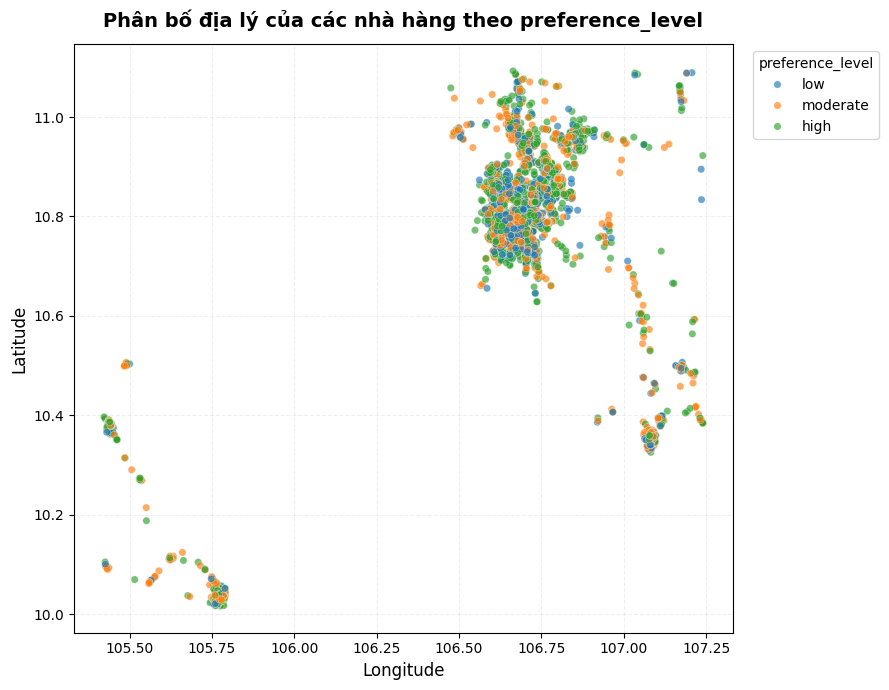

In [39]:
# Geography scatter plot (improved visualization)

geo_cols = ["Latitude", "Longitude"]

if all(col in final_df.columns for col in geo_cols + [TARGET_COL]):
    geo_df = final_df.dropna(subset=geo_cols + [TARGET_COL]).copy()

    # Chỉ lọc outlier để trực quan hóa cho dễ nhìn, KHÔNG thay đổi dữ liệu gốc
    lat_q1, lat_q99 = geo_df["Latitude"].quantile([0.01, 0.99])
    lon_q1, lon_q99 = geo_df["Longitude"].quantile([0.01, 0.99])

    geo_vis_df = geo_df[
        geo_df["Latitude"].between(lat_q1, lat_q99) &
        geo_df["Longitude"].between(lon_q1, lon_q99)
    ].copy()

    print(f"Số dòng dùng để visualize: {geo_vis_df.shape[0]:,}")
    print(f"Số dòng bị ẩn tạm thời do outlier tọa độ: {geo_df.shape[0] - geo_vis_df.shape[0]:,}")

    target_order = ["low", "moderate", "high"]
    target_order = [x for x in target_order if x in geo_vis_df[TARGET_COL].unique()]

    plt.figure(figsize=(9, 7))

    sns.scatterplot(
        data=geo_vis_df,
        x="Longitude",
        y="Latitude",
        hue=TARGET_COL,
        hue_order=target_order,
        alpha=0.65,
        s=28,
        edgecolor="white",
        linewidth=0.3
    )

    plt.title(
        "Phân bố địa lý của các nhà hàng theo preference_level",
        fontsize=14,
        fontweight="bold",
        pad=12
    )
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend(title="preference_level", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.grid(alpha=0.2, linestyle="--")
    plt.tight_layout()
    plt.show()

else:
    print("Không tìm thấy đủ Latitude, Longitude hoặc target trong dữ liệu.")

### Nhận xét:
* Nơi tập trung cao độ: Có một cụm rất lớn tập trung trong phạm vi Longitude từ ~106.5 đến 106.8 và Latitude từ ~10.7 đến 11.0. Đó chắc hẳn là khu vực trung tâm đô thị chính, nơi mật độ nhà hàng dày đặc nhất.
* Các cụm vệ tinh: Có các cụm nhỏ hơn nằm tách biệt ở phía Tây Nam (khoảng 105.5, 10.3) và Đông Nam (khoảng 107.1, 10.4). Điều này cho thấy dữ liệu bao phủ các khu vực ngoại ô và các thành phố/huyện nhỏ hơn
* Khoảng trống: Có một vùng trống rõ rệt giữa các cụm, cho thấy đây có thể là khu vực ít dân cư, khu công nghiệp, hoặc vùng không có dữ liệu nhà hàng.

## 12. Outlier Analysis

In [40]:
# Tạo bảng thống kê outlier cho các biến continuous

outlier_summary = []

for col in continuous_cols:
    result = count_outliers_iqr(final_df[col])

    outlier_summary.append({
        "feature": col,
        "outlier_count": result["outlier_count"],
        "outlier_ratio": result["outlier_ratio"],
        "lower_bound": result["lower_bound"],
        "upper_bound": result["upper_bound"],
        "iqr": result["iqr"],
        "note": result["note"]
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df = outlier_summary_df.sort_values(
    "outlier_count",
    ascending=False,
    na_position="last"
)

outlier_summary_df

,feature,outlier_count,outlier_ratio,lower_bound,upper_bound,iqr,note
0,Latitude,1825.0,18.68,10.624834,10.967011,0.085544,OK
1,Longitude,1782.0,18.24,106.536294,106.823800,0.071877,OK
12,Avg_close_hour,1261.0,12.91,19.500000,23.500000,1.000000,OK
13,Avg_open_duration,1193.0,12.21,7.000000,19.000000,3.000000,OK
11,Avg_open_hour,1059.0,10.84,2.500000,14.500000,3.000000,OK
2,Min_Price,651.0,6.66,-10500.000000,57500.000000,17000.000000,OK
9,Cuisines_Snack,624.0,6.39,-1.500000,2.500000,1.000000,OK
5,Price_range,537.0,5.50,-120019.500000,280032.500000,100013.000000,OK
4,Avg_Price,532.0,5.45,-63750.000000,206250.000000,67500.000000,OK
3,Max_Price,416.0,4.26,-125000.000000,315000.000000,110000.000000,OK


Một số feature có IQR = 0 do phần lớn giá trị bằng 0. Với các feature dạng thưa hoặc count-like, kết quả IQR dễ gắn nhãn các giá trị khác 0 là outlier. Vì vậy, các feature này không được diễn giải là lỗi dữ liệu mà chỉ phản ánh phân phối lệch mạnh/zero-inflated.

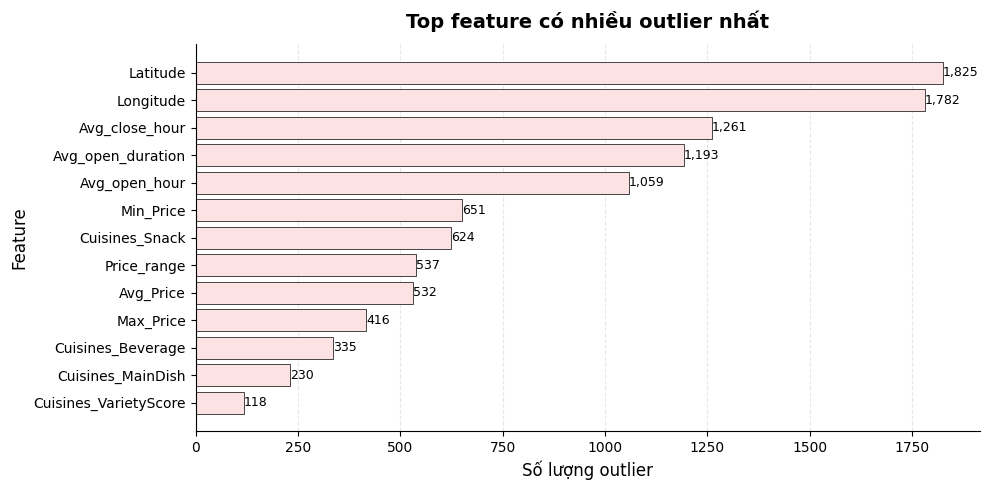

In [41]:
# Vẽ top 15 feature có nhiều outlier nhất

outlier_plot_df = outlier_summary_df.dropna(subset=["outlier_count"]).copy()

plot_barh_beautiful(
    data=outlier_plot_df,
    category_col="feature",
    value_col="outlier_count",
    title="Top feature có nhiều outlier nhất",
    xlabel="Số lượng outlier",
    ylabel="Feature",
    color=PASTEL_COLORS["pink"],
    top_n=15,
    value_format="{:,.0f}"
)

## 13. Statistical Tests

### 13.1 Chi-square test for binary features

In [42]:
#Chi-square test for binary features 

from scipy.stats import chi2_contingency

# Chọn top 20 binary feature phổ biến nhất để kiểm định
# Tránh bảng kết quả quá dài do dữ liệu có nhiều biến one-hot

top_binary_for_test = (
    binary_ratio_df
    .sort_values("positive_ratio", ascending=False)
    .head(20)["feature"]
    .tolist()
)

chi_square_results = []

for col in top_binary_for_test:
    contingency_table = pd.crosstab(final_df[col], final_df[TARGET_COL])

    if contingency_table.shape[0] >= 2 and contingency_table.shape[1] >= 2:
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)

        chi_square_results.append({
            "feature": col,
            "chi2": round(chi2, 4),
            "p_value": p_value,
            "dof": dof,
            "significant_0.05": p_value < 0.05
        })

chi_square_results_df = (
    pd.DataFrame(chi_square_results)
    .sort_values("p_value")
    .reset_index(drop=True)
)

display(chi_square_results_df)

,feature,chi2,p_value,dof,significant_0.05
0,Has_Wifi,273.2670,4.579644e-60,2,True
1,Style_Taiwanese,207.8590,7.311316e-46,2,True
2,Style_Chinese,181.1891,4.521477e-40,2,True
3,Style_Thai,157.5562,6.124991e-35,2,True
4,Type_nhà hàng,148.6062,5.377449e-33,2,True
5,Type_quán ăn,136.2422,2.602453e-30,2,True
6,Is_open_weekend,112.5932,3.553756e-25,2,True
7,Has_Table_booking,84.4989,4.480183e-19,2,True
8,Style_Asian,51.0146,8.362117e-12,2,True
9,Type_tiệm bánh,49.5495,1.739685e-11,2,True


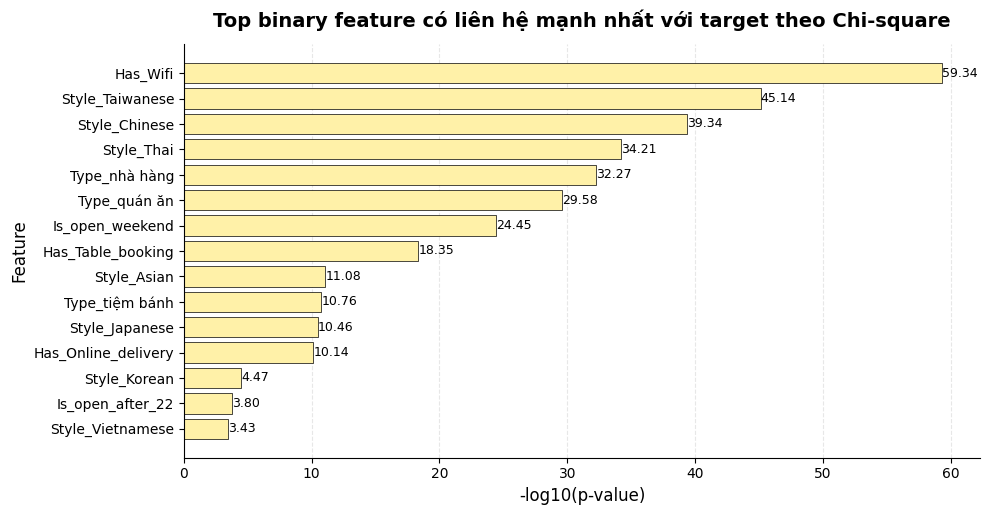

In [43]:
# Vẽ top binary feature có p-value nhỏ nhất

chi_square_plot_df = chi_square_results_df.head(15).copy()

chi_square_plot_df["minus_log10_p"] = -np.log10(
    chi_square_plot_df["p_value"].clip(lower=1e-300)
)

plot_barh_beautiful(
    data=chi_square_plot_df,
    category_col="feature",
    value_col="minus_log10_p",
    title="Top binary feature có liên hệ mạnh nhất với target theo Chi-square",
    xlabel="-log10(p-value)",
    ylabel="Feature",
    color=PASTEL_COLORS["yellow"],
    top_n=None,
    value_format="{:.2f}"
)

### Nhận xét:
* Chi-square test được sử dụng để kiểm tra mối liên hệ giữa các biến nhị phân/one-hot và biến mục tiêu `preference_level`.  
* Kết quả có p-value càng nhỏ, đồng nghĩa giá trị -log10(p-value) càng lớn, khả năng giả thuyết "không có mối liên hệ nào" là cực kỳ thấp (tức là mối liên hệ giữa feature và target có ý nghĩa thống kê). Tuy nhiên, kiểm định này chỉ phản ánh mối liên hệ thống kê, không chứng minh quan hệ nhân quả.

### 13.2 Kruskal-Wallis test for continuous features

In [44]:
# Kruskal-Wallis test for continuous features 

from scipy.stats import kruskal

# Kiểm định Kruskal-Wallis cho các biến continuous theo target
# Phù hợp hơn ANOVA khi dữ liệu lệch và có outlier

kruskal_results = []

for col in important_continuous_cols:
    groups = [
        group[col].dropna()
        for _, group in final_df.groupby(TARGET_COL)
    ]

    if all(len(g) >= 2 for g in groups):
        stat, p_value = kruskal(*groups)

        kruskal_results.append({
            "feature": col,
            "statistic": round(stat, 4),
            "p_value": p_value,
            "significant_0.05": p_value < 0.05
        })

kruskal_results_df = (
    pd.DataFrame(kruskal_results)
    .sort_values("p_value")
    .reset_index(drop=True)
)

display(kruskal_results_df)

,feature,statistic,p_value,significant_0.05
0,Min_Price,94.0509,3.776701e-21,True
1,Avg_open_hour,31.0428,1.816108e-07,True
2,Avg_Price,13.4648,1.191696e-03,True
3,Avg_open_duration,5.7181,5.732277e-02,False
4,Max_Price,1.7949,4.075976e-01,False
5,Price_range,0.7566,6.850270e-01,False


## Nhận xét:
* Nhóm ảnh hưởng mạnh nhất: Các cột có statistic cao và p_value cực nhỏ có ý nghĩa phân loại quan trọng như Cuisines_MainDish (86.04), Cuisines_VarietyScore (73.38), Min_Price (94.05)
* Nhóm ảnh hưởng vừa phải (có ảnh hưởng thấp hơn nhưng mang lại thông tin hữu ích, đóng góp đáng kể trong việc dự đoán): Latitude (30.9), Cuisines_Snack (28.16), Avg_close_hour (27.06), Longitude (7.69) & Avg_open_hour (31.04)
* Nhóm "nhiễu" không có ý nghĩa: Price_range (0.76), Cuisines_Beverage (3.43), Max_Price (1.79), Avg_open_duration (5.72) có thể loại bỏ

## 14. Summary of Findings

In [45]:
# Tính một số chỉ số tổng kết

majority_row = target_distribution.sort_values("count", ascending=False).iloc[0]
majority_class = majority_row[TARGET_COL]
majority_ratio = majority_row["ratio (%)"]

rare_feature_count = int((binary_ratio_df["positive_ratio"] < 1).sum()) if len(binary_ratio_df) > 0 else 0

n_original_columns = final_df.drop(columns=[TARGET_NUMERIC_COL], errors="ignore").shape[1]

n_iqr_zero_features = (
    int((outlier_summary_df["iqr"] == 0).sum())
    if "iqr" in outlier_summary_df.columns
    else 0
)

n_invalid_price_range = (
    int((final_df["Price_range"] < 0).sum())
    if "Price_range" in final_df.columns
    else "Không có cột Price_range"
)

summary_findings = pd.DataFrame([
    {
        "Nội dung kiểm tra": "Số dòng dữ liệu sau khi bỏ trùng",
        "Kết quả": final_df.shape[0],
        "Ý nghĩa": "Số lượng mẫu cuối cùng dùng cho EDA/model"
    },
    {
        "Nội dung kiểm tra": "Số cột dữ liệu gốc",
        "Kết quả": n_original_columns,
        "Ý nghĩa": "Tổng số cột gốc, không tính cột phụ tạo thêm cho phân tích"
    },
    {
        "Nội dung kiểm tra": "Tổng số giá trị thiếu",
        "Kết quả": total_missing,
        "Ý nghĩa": "Đánh giá dữ liệu còn missing hay không"
    },
    {
        "Nội dung kiểm tra": "Số dòng duplicate đã loại bỏ",
        "Kết quả": duplicate_rows_to_drop,
        "Ý nghĩa": "Giảm trùng lặp trước khi phân tích/modeling"
    },
    {
        "Nội dung kiểm tra": "Số biến nhị phân/one-hot",
        "Kết quả": len(binary_cols),
        "Ý nghĩa": "Số lượng feature dạng nhị phân hoặc one-hot"
    },
    {
        "Nội dung kiểm tra": "Số biến định lượng không nhị phân",
        "Kết quả": len(continuous_cols),
        "Ý nghĩa": "Số lượng feature liên tục cần kiểm tra phân bố/outlier"
    },
    {
        "Nội dung kiểm tra": "Lớp mục tiêu chiếm đa số",
        "Kết quả": f"{majority_class} ({majority_ratio}%)",
        "Ý nghĩa": "Đánh giá mức độ mất cân bằng lớp"
    },
    {
        "Nội dung kiểm tra": "Số binary feature có tỷ lệ xuất hiện dưới 1%",
        "Kết quả": rare_feature_count,
        "Ý nghĩa": "Đánh giá mức độ thưa/hiếm của feature one-hot"
    },
    {
        "Nội dung kiểm tra": "Số feature có IQR = 0",
        "Kết quả": n_iqr_zero_features,
        "Ý nghĩa": "Các feature này không nên diễn giải outlier theo IQR thông thường"
    },
    {
        "Nội dung kiểm tra": "Số dòng có Price_range âm",
        "Kết quả": n_invalid_price_range,
        "Ý nghĩa": "Dấu hiệu cần kiểm tra lại logic tạo đặc trưng giá"
    }
])

display(summary_findings)

,Nội dung kiểm tra,Kết quả,Ý nghĩa
0,Số dòng dữ liệu sau khi bỏ trùng,9768,Số lượng mẫu cuối cùng dùng cho EDA/model
1,Số cột dữ liệu gốc,54,"Tổng số cột gốc, không tính cột phụ tạo thêm cho phân tích"
2,Tổng số giá trị thiếu,0,Đánh giá dữ liệu còn missing hay không
3,Số dòng duplicate đã loại bỏ,0,Giảm trùng lặp trước khi phân tích/modeling
4,Số biến nhị phân/one-hot,39,Số lượng feature dạng nhị phân hoặc one-hot
5,Số biến định lượng không nhị phân,14,Số lượng feature liên tục cần kiểm tra phân bố/outlier
6,Lớp mục tiêu chiếm đa số,high (36.01%),Đánh giá mức độ mất cân bằng lớp
7,Số binary feature có tỷ lệ xuất hiện dưới 1%,12,Đánh giá mức độ thưa/hiếm của feature one-hot
8,Số feature có IQR = 0,1,Các feature này không nên diễn giải outlier theo IQR thông thường
9,Số dòng có Price_range âm,0,Dấu hiệu cần kiểm tra lại logic tạo đặc trưng giá


### Kết luận EDA dữ liệu final chưa scale

Tập dữ liệu final chưa scale đã được xử lý về dạng phù hợp để phân tích và chuẩn bị cho mô hình, đồng thời vẫn giữ được ý nghĩa gốc của các feature liên tục. Sau khi kiểm tra duplicate, nhóm loại bỏ các dòng trùng hoàn toàn để hạn chế nguy cơ làm sai lệch phân bố dữ liệu.

Biến mục tiêu `preference_level` đã áp dụng phương pháp quantile để giảm mức độ mất cân bằng lớp.

Ngoài ra, một số feature nhị phân xuất hiện rất hiếm và một số biến liên tục có outlier.